In [60]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import xarray as xr
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import glob

sys.path.append(str(Path("../src").resolve()))
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity
from radar_lwc.preprocessing.clean import drop_duplicate_times
from radar_lwc.preprocessing.align import align_to_reference_time
from radar_lwc.retrieval.kappa_liquid import kappa_liquid
from radar_lwc.retrieval.dielectric import epsilon_water_liebe1989
from radar_lwc.retrieval.zhu import retrieve_lwc_zhu

In [61]:
in_path = Path("../data/processed/aligned_LWP2.nc")
ds = xr.open_dataset(in_path)
print(ds)

<xarray.Dataset> Size: 43MB
Dimensions:  (Time: 10441, range: 339)
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt     (range) float32 1kB ...
Data variables:
    Ze_W     (Time, range) float32 14MB ...
    Ze_Ka    (Time, range) float32 14MB ...
    T_cloud  (Time, range) float32 14MB ...
    LWP      (Time) float32 42kB ...
Attributes:
    description:  Aligned W/Ka reflectivities + T field for LWC retrieval
    date:         20230928
    site:         Cabauw
    Ze_units:     dBZ
    created_by:   02_align.ipynb


=================================================

DWR HERE FIRST

=================================================

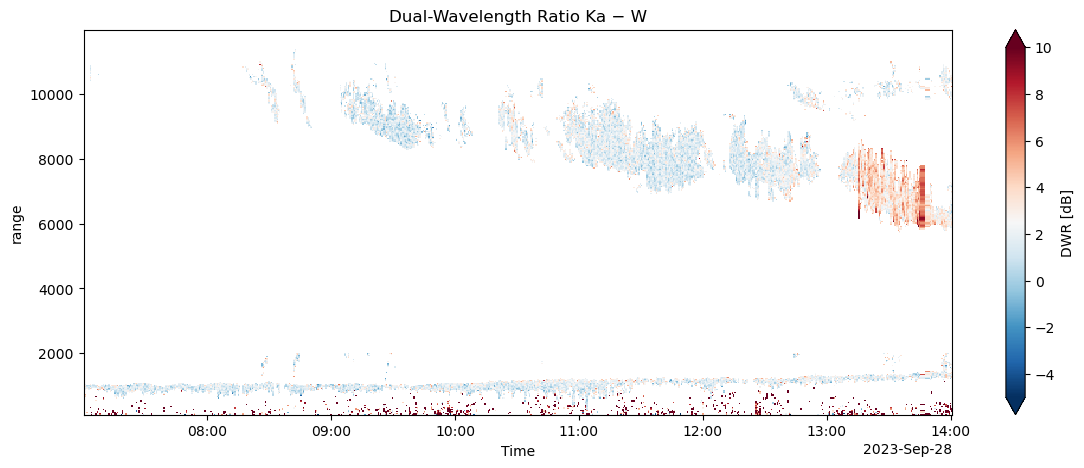

In [62]:
dwr = ds["Ze_Ka"]- ds["Ze_W"]      # in dB
dwr.name = "DWR"
dwr.attrs["units"] = "dB"
fig, ax = plt.subplots(figsize=(14, 5))
dwr.plot(x="Time", y="range", cmap="RdBu_r", vmin=-5, vmax=10, ax=ax, cbar_kwargs={"label": "DWR [dB]"})
ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

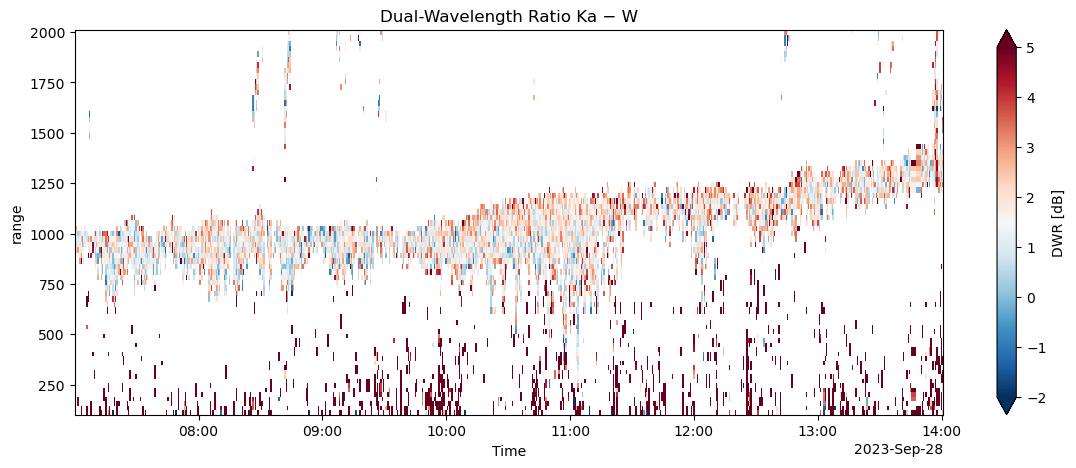

In [63]:
dwr_2km = dwr.sel(range=slice(0, 2000))

fig, ax = plt.subplots(figsize=(14, 5))

dwr_2km.plot(
    x="Time",
    y="range",
    cmap="RdBu_r",
    vmin=-2,
    vmax=5,
    ax=ax,
    cbar_kwargs={"label": "DWR [dB]"}
)

ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

In [64]:
# 1. Confirm DWR is in dB
print("DWR stats (cloud only):")
cloud_dwr = dwr.where(dwr > -5).where(dwr < 20)  # rough cloud filter
print(f"  median: {float(cloud_dwr.median()):.2f}")
print(f"  90th pct: {float(cloud_dwr.quantile(0.9)):.2f}")       # 90% of DWR are below 4.49dB
print(f"  range: {float(cloud_dwr.min()):.2f} to {float(cloud_dwr.max()):.2f}")

# 2. Confirm range axis
print(f"\nRange axis: first={float(dwr['range'][0]):.1f} m, last={float(dwr['range'][-1]):.1f} m")
print(f"Δh = {float(dwr['range'][1] - dwr['range'][0]):.1f} m")

# 3. Check kappa
print(f"\nkappa_W: {float(kappa_w.mean()):.3f} dB/km/(g/m³)")
print(f"kappa_Ka: {float(kappa_ka.mean()):.3f} dB/km/(g/m³)")
print(f"Δκ: {float((kappa_w - kappa_ka).mean()):.3f}")


DWR stats (cloud only):
  median: 2.00
  90th pct: 4.49
  range: -5.00 to 20.00

Range axis: first=111.8 m, last=11974.8 m
Δh = 22.4 m

kappa_W: 4.290 dB/km/(g/m³)
kappa_Ka: 0.800 dB/km/(g/m³)
Δκ: 3.490


===============================

KAPPA AND ALPHA CALCULATION AND PLACEHOLDERS FOR NOW

====================================

In [65]:
alpha_w = xr.DataArray(
    np.full_like(dwr.values, 0.65),
    dims=dwr.dims,
    coords=dwr.coords,
    name="alpha_W",
)

alpha_ka = xr.DataArray(
    np.full_like(dwr.values, 0.14),
    dims=dwr.dims,
    coords=dwr.coords,
    name="alpha_Ka",
)

In [66]:
kappa_w = xr.DataArray(
    np.full_like(dwr.values, 4.29),
    dims=dwr.dims,
    coords=dwr.coords,
    name="kappa_W",
)

kappa_ka = xr.DataArray(
    np.full_like(dwr.values, 0.80),
    dims=dwr.dims,
    coords=dwr.coords,
    name="kappa_Ka",
)

====================================

CLOUD MASK PLACEHOLDER AND FIRST TRY TO IMPLEMENT EARLY VERSION

====================================

In [67]:
# cloud_mask = xr.DataArray(
#     np.ones_like(dwr.values, dtype=bool),
#     dims=dwr.dims,
#     coords=dwr.coords,
#     name="cloud_mask",
# )

In [68]:
# %% Real cloud mask (replace the all-True placeholder)
# Cloud = both radars see a return above noise floor.
# -40 dBZ is a conservative Ka-band cloud detection threshold.
cloud_mask = (
    ds["Ze_Ka"].notnull()
    & ds["Ze_W"].notnull()
    & (ds["Ze_Ka"] > -40)
    & (ds["Ze_W"] > -40)
)
cloud_mask.name = "cloud_mask"
print(f"Cloud fraction (full column): {float(cloud_mask.mean()):.2%}")     # .2: two digits after decimal and %: that in percentage; .mean of Boolean array takes true as 1 and false as 0. So True divided by all Booleans in Array 

# 2 km version to match your existing workflow
cloud_mask_2km = cloud_mask.sel(range=slice(0, 2000))                  #.sel(range=slice(0, 2000)) only takes first 2 km
print(f"Cloud fraction (0–2 km):     {float(cloud_mask_2km.mean()):.2%}")


Cloud fraction (full column): 9.04%
Cloud fraction (0–2 km):     13.55%


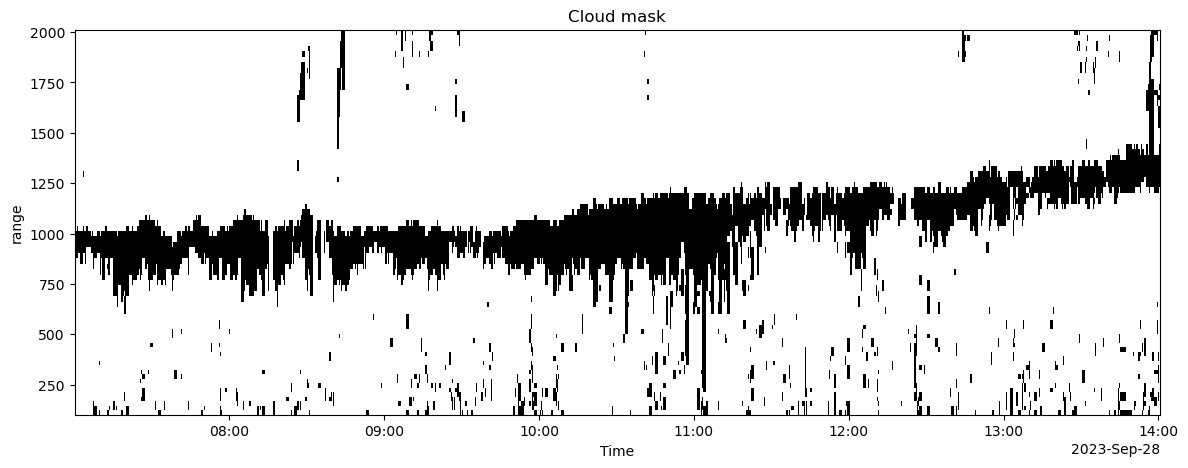

In [69]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

cloud_mask.sel(range=slice(0, 2000)).plot(
    x="Time",
    y="range",
    cmap="Greys",
    add_colorbar=False,
    ax=ax,
)

ax.set_title("Cloud mask")
plt.show()

SLICE ALL VALUES UP TO 2KM

In [70]:
dwr_2km = dwr.sel(range=slice(0, 2000))
cloud_mask_2km = cloud_mask.sel(range=slice(0, 2000))

alpha_w_2km = alpha_w.sel(range=slice(0, 2000))
alpha_ka_2km = alpha_ka.sel(range=slice(0, 2000))

kappa_w_2km = kappa_w.sel(range=slice(0, 2000))
kappa_ka_2km = kappa_ka.sel(range=slice(0, 2000))

In [72]:
# Cell FINAL — Save retrieval_input.nc

from pathlib import Path
import xarray as xr

ds_retrieval = xr.Dataset(
    {
        # Original radar measurements (useful for diagnostics)
        "Ze_W": ds["Ze_W"],
        "Ze_Ka": ds["Ze_Ka"],

        # Auxiliary data
        "T_cloud": ds["T_cloud"],
        "LWP": ds["LWP"],

        # Retrieval inputs
        "DWR": dwr.rename("DWR"),
        "cloud_mask": cloud_mask.rename("cloud_mask"),

        # Gas attenuation
        "alpha_W": alpha_w.rename("alpha_W"),
        "alpha_Ka": alpha_ka.rename("alpha_Ka"),

        # Liquid attenuation coefficients
        "kappa_W": kappa_w.rename("kappa_W"),
        "kappa_Ka": kappa_ka.rename("kappa_Ka"),
    },
    attrs={
        "description": "Prepared inputs for Zhu et al. (2019) LWC retrieval",
        "date": "20230928",
        "site": "Cabauw",
        "created_by": "03_dwr_and_masking.ipynb",
    },
)

out_path = Path("../data/processed/retrieval_input.nc")
out_path.parent.mkdir(parents=True, exist_ok=True)

ds_retrieval.to_netcdf(out_path)

print(f"Saved → {out_path}")
print(ds_retrieval)

Saved → ..\data\processed\retrieval_input.nc
<xarray.Dataset> Size: 117MB
Dimensions:     (Time: 10441, range: 339)
Coordinates:
  * Time        (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28...
  * range       (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt        (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
Data variables:
    Ze_W        (Time, range) float32 14MB nan nan nan -52.43 ... nan nan nan
    Ze_Ka       (Time, range) float32 14MB nan nan nan nan ... nan nan nan nan
    T_cloud     (Time, range) float32 14MB ...
    LWP         (Time) float32 42kB ...
    DWR         (Time, range) float32 14MB nan nan nan nan ... nan nan nan nan
    cloud_mask  (Time, range) bool 4MB False False False ... False False False
    alpha_W     (Time, range) float32 14MB 0.65 0.65 0.65 ... 0.65 0.65 0.65
    alpha_Ka    (Time, range) float32 14MB 0.14 0.14 0.14 ... 0.14 0.14 0.14
    kappa_W     (Time, range) float32 14MB 4.29 4.29 4.29 ... 

In [74]:
# Cell FINAL 2 KM— Save retrieval_input.nc

from pathlib import Path
import xarray as xr

ds_retrieval = xr.Dataset(
    {
        # Radar measurements
        "Ze_W": ds["Ze_W"].sel(range=slice(0, 2000)),
        "Ze_Ka": ds["Ze_Ka"].sel(range=slice(0, 2000)),

        # Auxiliary data
        "T_cloud": ds["T_cloud"].sel(range=slice(0, 2000)),
        "LWP": ds["LWP"],

        # Retrieval inputs
        "DWR": dwr_2km.rename("DWR"),
        "cloud_mask": cloud_mask_2km.rename("cloud_mask"),

        # Gas attenuation
        "alpha_W": alpha_w_2km.rename("alpha_W"),
        "alpha_Ka": alpha_ka_2km.rename("alpha_Ka"),

        # Liquid attenuation coefficients
        "kappa_W": kappa_w_2km.rename("kappa_W"),
        "kappa_Ka": kappa_ka_2km.rename("kappa_Ka"),
    },
    attrs={
        "description": "Prepared inputs for Zhu et al. (2019) LWC retrieval (0–2 km)",
        "date": "20230928",
        "site": "Cabauw",
        "created_by": "03_dwr_and_masking.ipynb",
    },
)

out_path = Path("../data/processed/retrieval_input_2km.nc")
out_path.parent.mkdir(parents=True, exist_ok=True)

ds_retrieval.to_netcdf(out_path)

print(f"Saved → {out_path}")
print(ds_retrieval)

Saved → ..\data\processed\retrieval_input_2km.nc
<xarray.Dataset> Size: 26MB
Dimensions:     (Time: 10441, range: 74)
Coordinates:
  * Time        (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28...
  * range       (range) float32 296B 111.8 134.2 156.5 ... 1.971e+03 1.998e+03
    TAlt        (range) float32 296B 111.8 134.2 156.5 ... 1.971e+03 1.998e+03
Data variables:
    Ze_W        (Time, range) float32 3MB nan nan nan -52.43 ... nan nan nan nan
    Ze_Ka       (Time, range) float32 3MB nan nan nan nan ... nan nan nan nan
    T_cloud     (Time, range) float32 3MB ...
    LWP         (Time) float32 42kB ...
    DWR         (Time, range) float32 3MB nan nan nan nan ... nan nan nan nan
    cloud_mask  (Time, range) bool 773kB False False False ... False False False
    alpha_W     (Time, range) float32 3MB 0.65 0.65 0.65 0.65 ... 0.65 0.65 0.65
    alpha_Ka    (Time, range) float32 3MB 0.14 0.14 0.14 0.14 ... 0.14 0.14 0.14
    kappa_W     (Time, range) float32 3MB 4.29 4